# Saliency Plots

The goal of this script is to plot the deeplift scores for each input on an intuitive genomic map.

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools
from Bio import SeqIO
from Bio.Seq import Seq
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import vcf
import scipy.stats as st

from saliency_utils import *
from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

2022-12-29 17:55:26.268469: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-12-29 17:55:26.268525: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


4411532


In [2]:
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")

freschi_snps = pd.read_excel("Freschi_SNPs.xlsx")
# freschi_snps["position"] = freschi_snps["position"].astype(int)

#moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")
#gyrBA_variants = moxi_isolate_variants.query("POS >= 4998 & POS <= 9818")
#df_phenos_moxi = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/data_with_paths.csv")

tb_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

# Code to compare MICs between isolates with and without canonical gyrBA mutations

In [3]:
# aa_code_dict = {'Val':'V', 'Ile':'I', 'Leu':'L', 'Glu':'E', 'Gln':'Q', \
# 'Asp':'D', 'Asn':'N', 'His':'H', 'Trp':'W', 'Phe':'F', 'Tyr':'Y',    \
# 'Arg':'R', 'Lys':'K', 'Ser':'S', 'Thr':'T', 'Met':'M', 'Ala':'A',    \
# 'Gly':'G', 'Pro':'P', 'Cys':'C'}

# code_aa_dict = {value: key for key, value in aa_code_dict.items()}


# cat12_moxi = who_variants.loc[(who_variants.drug == 'MXF') & (who_variants.confidence.str.contains('|'.join(['1', '2'])))]
# cat12_moxi["genome_index"] = cat12_moxi["genome_index"].astype(int)
# cat12_moxi_variants = cat12_moxi.genome_index.unique()

# aa_variants = []
# for _, row in cat12_moxi.iterrows():
    
#     genome_pos = row["genome_index"]
#     expand_AA_change = list(row["variant"].split("_")[1])

#     expand_AA_change[0] = code_aa_dict[expand_AA_change[0]]
#     expand_AA_change[-1] = code_aa_dict[expand_AA_change[-1]]
    
#     expand_AA_change = "".join(expand_AA_change)
    
#     aa_variants.append(expand_AA_change)
    
    
# who_status = []
# for _, row in gyrBA_variants.iterrows():

#     found_var = False

#     if row["POS"] in cat12_moxi_variants:
    
#         for change in aa_variants:
#             if change in row["ANN"]:
#                 who_status.append(1)
#                 found_var = True
#                 break

#     if not found_var:
#         who_status.append(0)
            
# gyrBA_variants["WHO"] = np.array(who_status).astype(int)

# print(gyrBA_variants.WHO.value_counts())
# print(f"{len(gyrBA_variants.query('WHO == 1').Isolate.unique())} isolates have canonical gyrBA mutations")

In [4]:
# # isolates_with_gyrBA_mut = gyrBA_variants.query('WHO == 1').Isolate.unique()
# # pd.Series(isolates_with_gyrBA_mut).to_csv("isolates_with_gyrBA_mut.txt", sep="\t", index=False, header=None)

# isolates_with_gyrBA_mut = pd.read_csv("isolates_with_gyrBA_mut.txt", sep="\t", header=None)[0].values
# isolates_with_rpoBC_mut = pd.read_csv("isolates_with_rpoBC_mut.txt", sep="\t", header=None)[0].values
# len(isolates_with_gyrBA_mut), len(isolates_with_rpoBC_mut)

# Rifampicin

1 loci!
58 Cat 1/2 WHO catalog sites for ['RIF']
8 Cat 1/2 WHO catalog sites not found
Sites not found: [761080 761082 761094 761134 761135 761150 761151 761159]


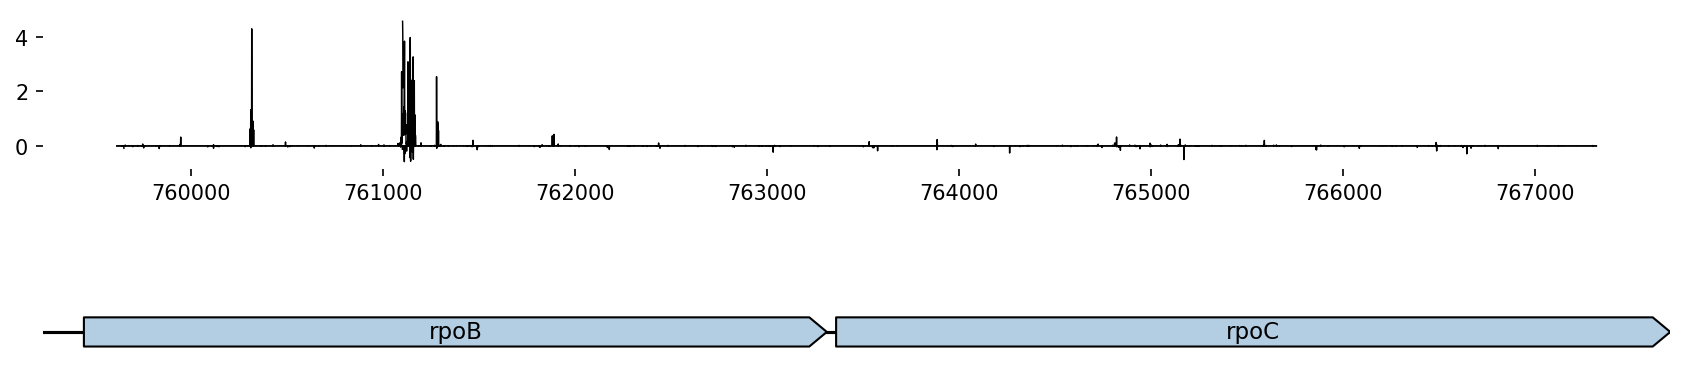

In [5]:
rif_rpoBC_df, rif_rpoBC_seqDict = generate_saliency_plots("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC",
                                                          "../config_rif.yaml",
                                                          ["RIF"],
                                                          cat_to_check=["1", "2"],
                                                          binary=False,
                                                          save=True
                                                         )

1 loci!
58 Cat 1/2 WHO catalog sites for ['RIF']
7 Cat 1/2 WHO catalog sites not found
Sites not found: [761080 761082 761094 761134 761135 761150 761159]


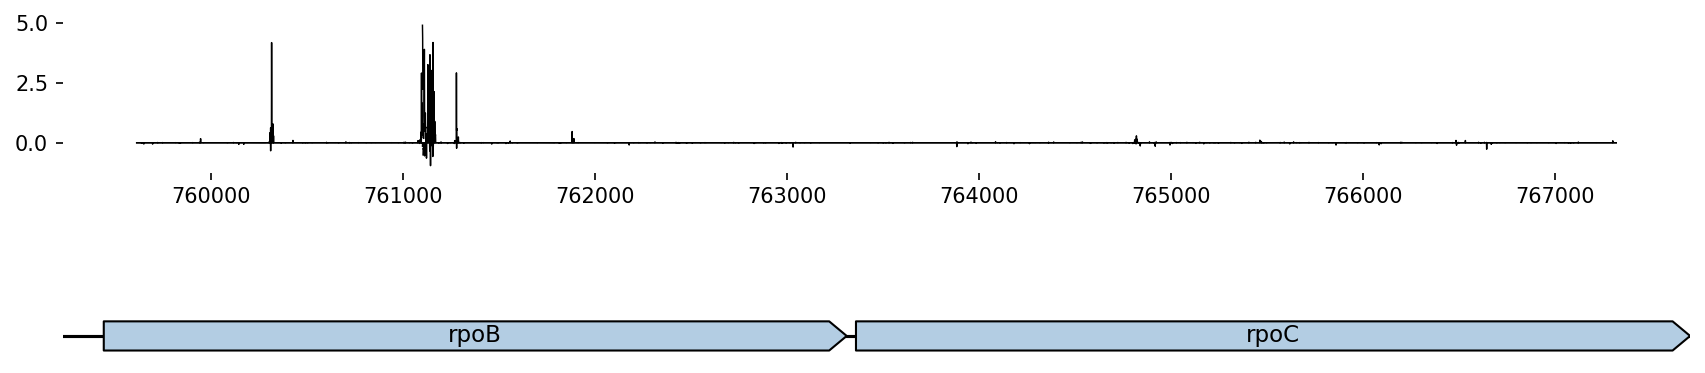

In [6]:
rif_rpoBC_lineage_df, rif_rpoBC_lineage_seqDict = generate_saliency_plots("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage",
                                                                          "../config_rif.yaml",
                                                                          ["RIF"],
                                                                          cat_to_check=["1", "2"],
                                                                          binary=False,
                                                                          save=True
                                                                         )

In [8]:
rif_rpoBC_lineage_df.sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP
1535,rpoBC,761100.0,4.904564,-0.136225,0.009068,1,0
1536,rpoBC,761101.0,4.369009,0.0,0.013618,1,0
1596,rpoBC,761155.0,4.185051,0.0,1.089662,1,0
731,rpoBC,760314.0,4.181377,0.0,0.010364,1,0
1551,rpoBC,761110.0,3.898471,0.0,0.195550,1,0
...,...,...,...,...,...,...,...
2714,rpoBC,762267.0,0.0,0.0,0.000000,0,0
2713,rpoBC,762266.0,0.0,0.0,0.000000,0,0
2712,rpoBC,762265.0,0.0,0.0,0.000000,0,0
2711,rpoBC,762264.0,0.0,0.0,0.000000,0,0


In [10]:
rif_rpoBC_lineage_df.Pos.values

array([759611.0, 759612.0, 759613.0, ..., 767318.0, 767319.0, 767320.0],
      dtype=object)

In [52]:
df_phenos = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

lineages = pd.get_dummies(df_phenos["Lineage"])

lineage_scores = np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage/saliency/quant/lineage_scores.npy")
# lineage_scores_df = pd.DataFrame(lineage_scores)
# lineage_scores_df.columns = lineages.columns
# lineage_scores_df.index = df_phenos.query("category=='original_train_set'")["ROLLINGDB_ID"].values

lineage_max = lineage_scores.max(axis=0)
lineage_min = lineage_scores.min(axis=0)

lineage_scores_df = pd.DataFrame({"Lineage": lineages.columns, "Max": lineage_max, "Min": lineage_min})
lineage_scores_df["Primary"] = [val.split(".")[0] for val in lineage_scores_df["Lineage"].values]

In [53]:
lineage_scores_df.groupby("Primary")[["Max", "Min"]].mean()

,Max,Min
Primary,,
1,0.103692,-0.256472
2,0.101649,-0.349168
3,0.047900,-0.262378
4,0.140172,-0.210347
BOV_AFRI,0.000000,-1.289613


In [55]:
df_phenos.groupby("Primary_Lineage")["RIF_midpoint"].agg(["mean", "median"])

,mean,median
Primary_Lineage,,
1,1.574636,0.030
2,4.227101,4.000
3,3.019117,3.000
4,8.555895,0.375
BOVAFRI,3.350000,0.015


In [56]:
df_phenos.Primary_Lineage.value_counts()

4          4893
2          3041
3           849
1           550
BOVAFRI      18
Name: Primary_Lineage, dtype: int64

In [57]:
np.exp(0.4)

1.4918246976412703

1 loci!
11 Cat 1/2 WHO catalog sites for ['MXF']
CNN found all Cat 1/2 WHO catalog sites for ['MXF']


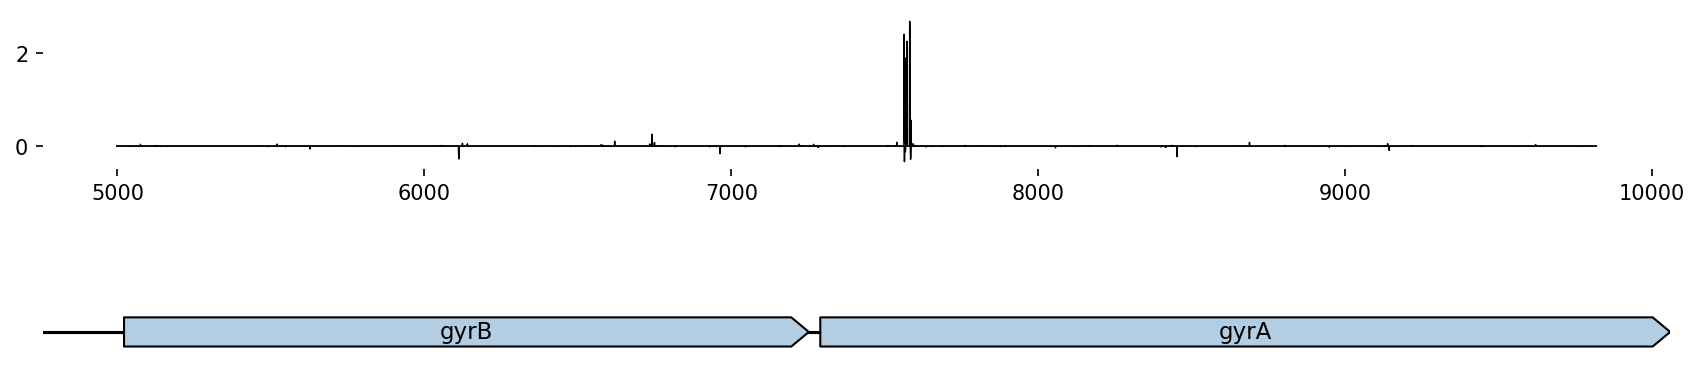

In [36]:
moxi_gyrBA_df, moxi_gyrBA_seqDict = generate_saliency_plots("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MOXI_gyrBA",
                                                            "../config.yaml",
                                                            ["MXF"],
                                                             cat_to_check=["1", "2"],
                                                             binary=False,
                                                             save=True
                                                            )

1 loci!
11 Cat 1/2 WHO catalog sites for ['MXF']
CNN found all Cat 1/2 WHO catalog sites for ['MXF']


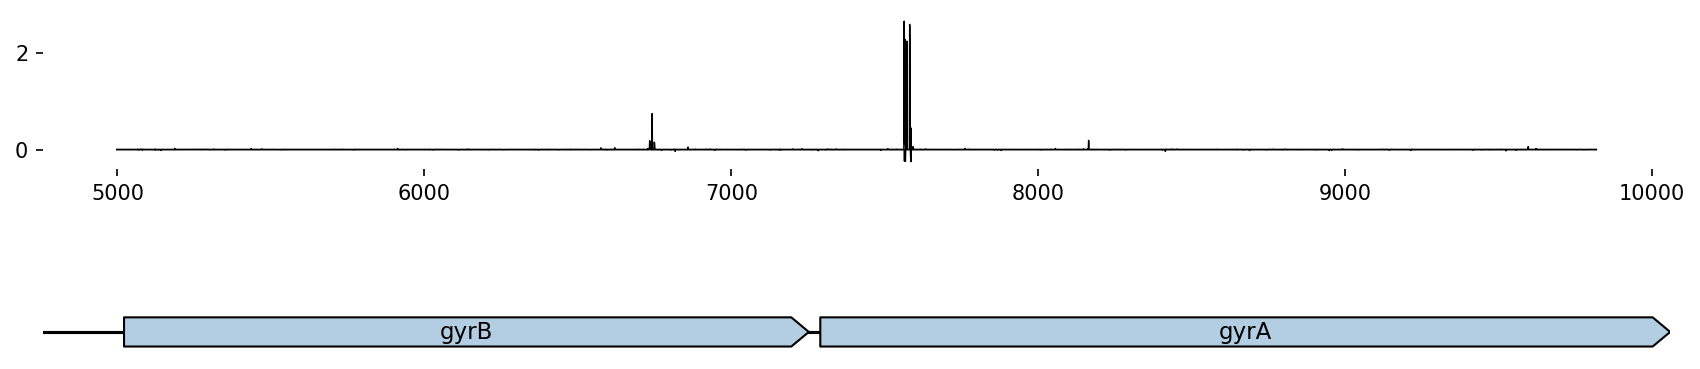

In [34]:
moxi_gyrBA_lineage_df, moxi_gyrBA_lineage_seqDict = generate_saliency_plots("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MOXI_gyrBA_lineage",
                                                                            "../config_moxi_lineage.yaml",
                                                                            ["MXF"],
                                                                             cat_to_check=["1", "2"],
                                                                             binary=False,
                                                                             save=True
                                                                            )

5 loci!
11 Cat 1/2 WHO catalog sites for ['MXF']
CNN found all Cat 1/2 WHO catalog sites for ['MXF']


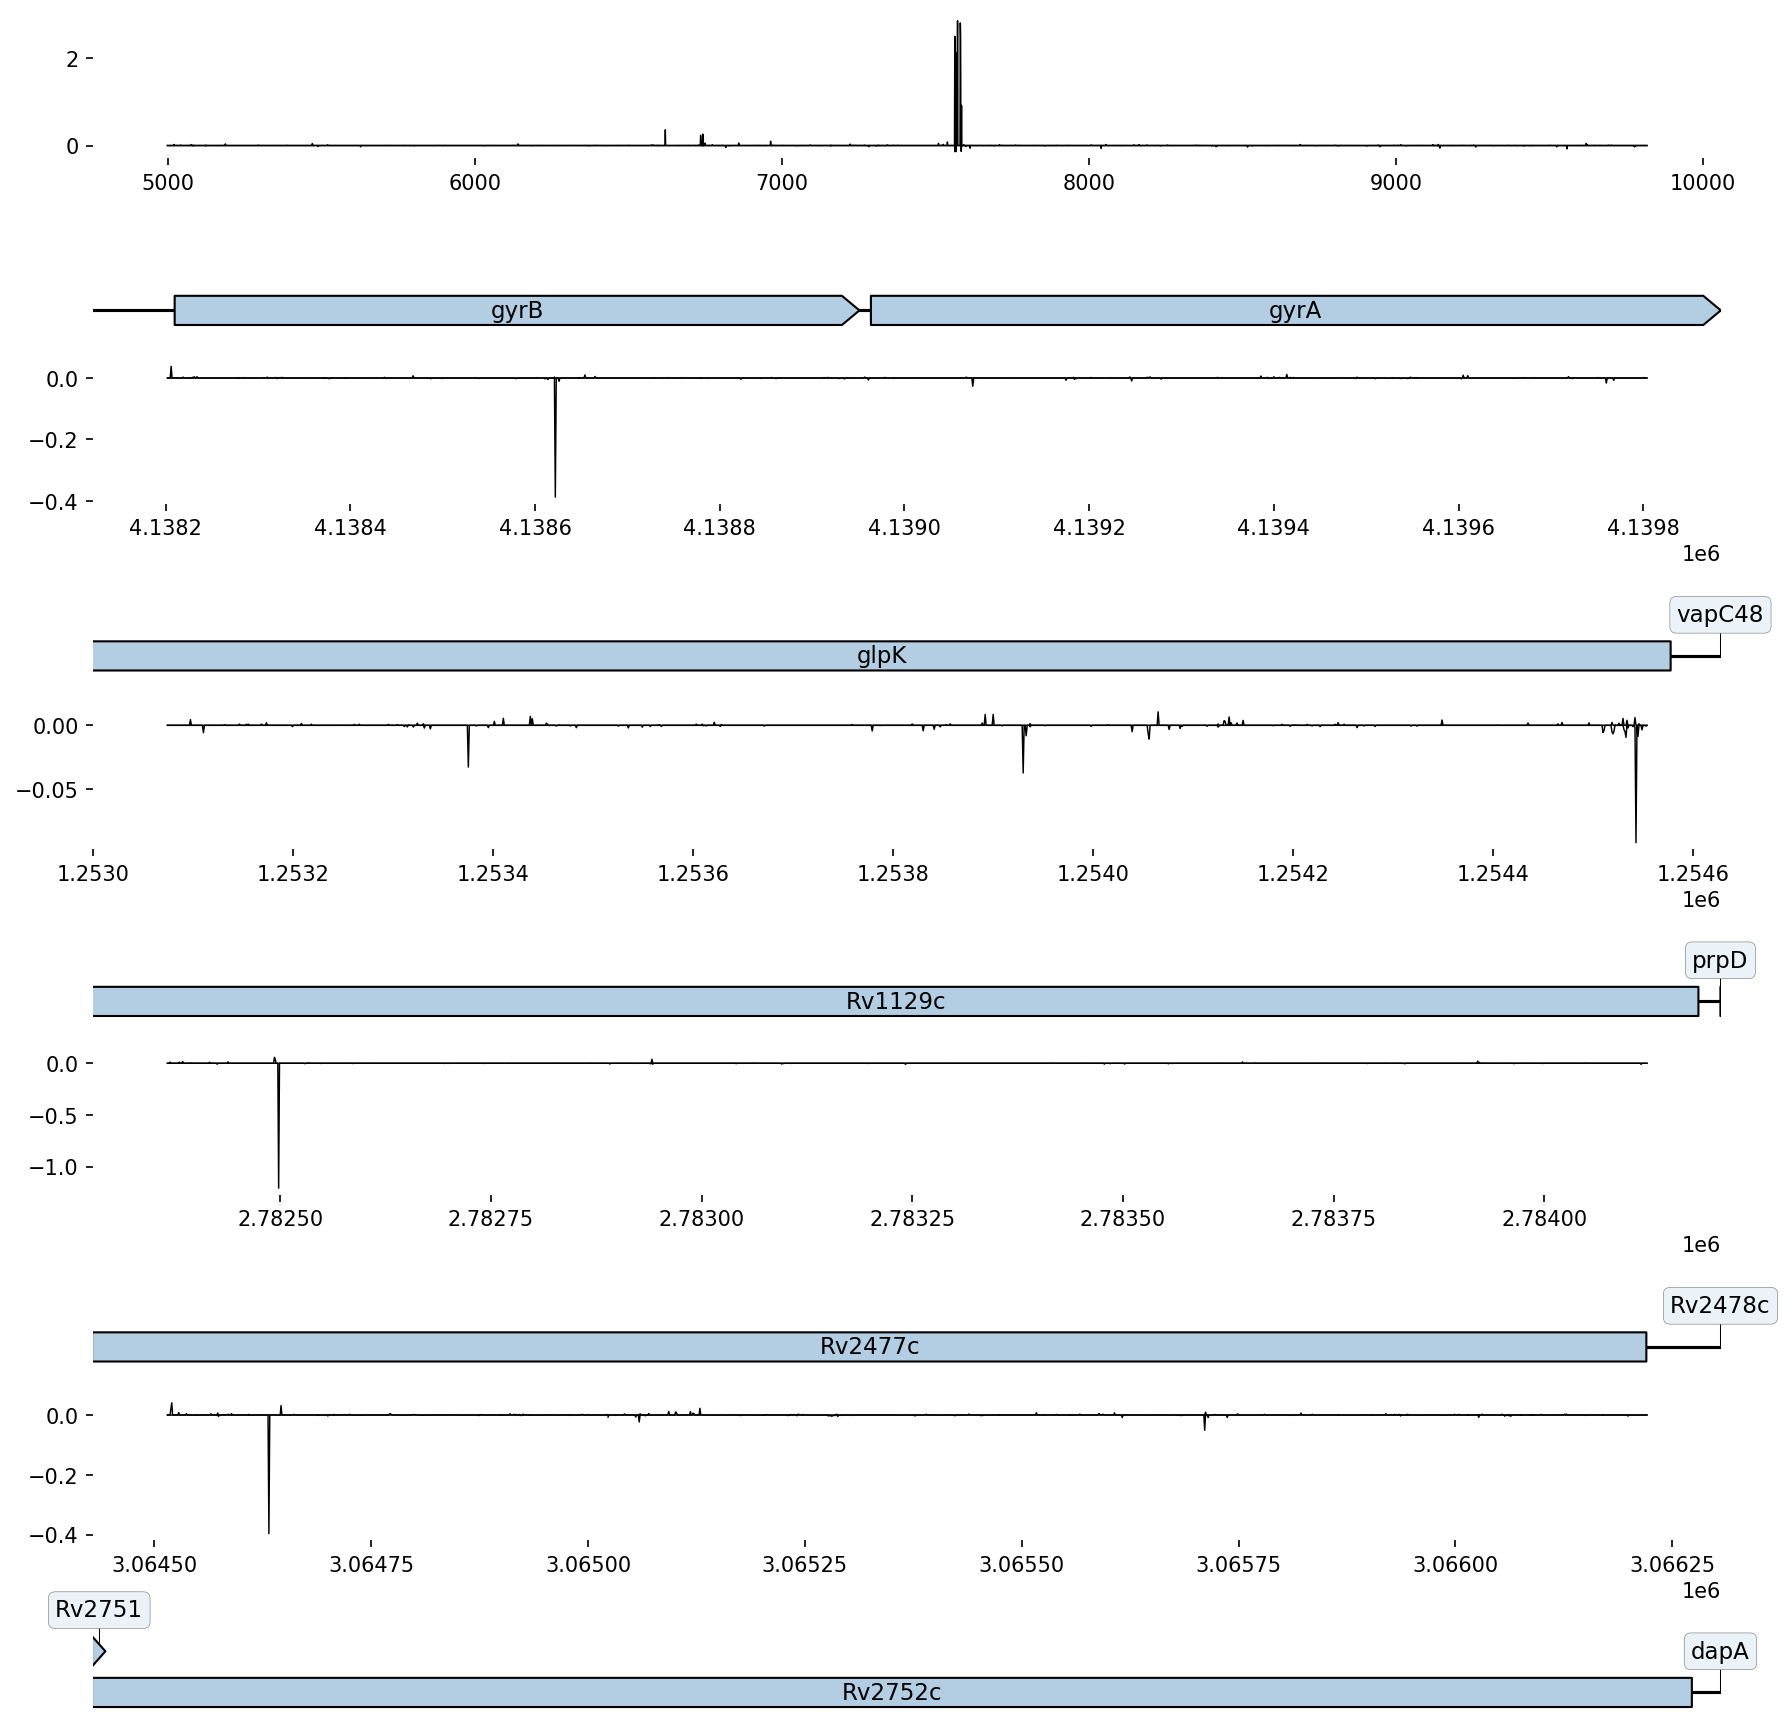

In [37]:
moxi_5loci_lineage_df, moxi_5loci_lineage_seqDict = generate_saliency_plots("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MOXI_5Loci",
                                                                            "../config_moxi_multi.yaml",
                                                                            ["MXF"],
                                                                             cat_to_check=["1", "2"],
                                                                             binary=False,
                                                                             save=True
                                                                            )

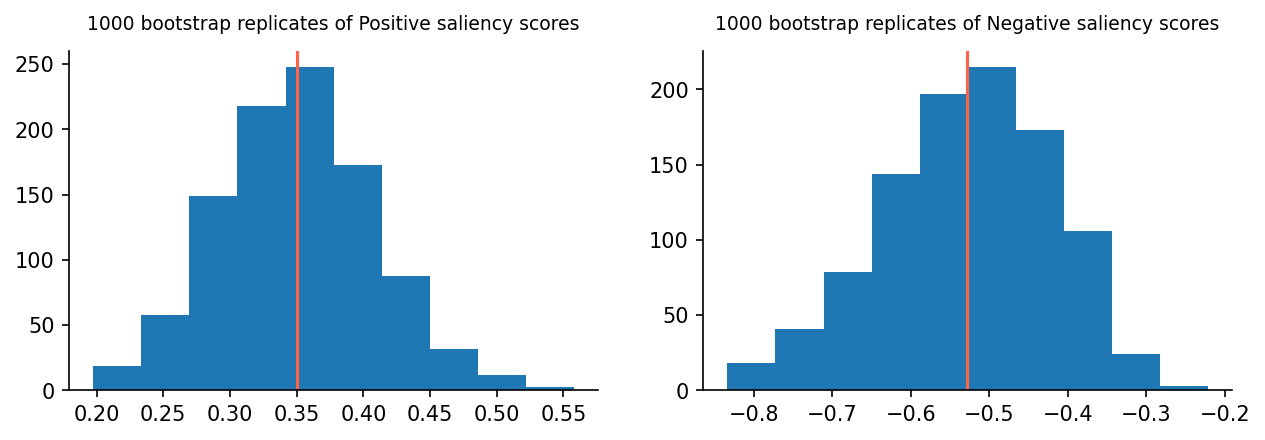

In [243]:
min_scores = np.min(lineage_scores, axis=0)
max_scores = np.max(lineage_scores, axis=0)

moxi_snps["Max"] = max_scores
moxi_snps["Min"] = min_scores
# min_scores = moxi_gyrBA_lineage2_df.query("Min < 0")["Min"].values
# max_scores = moxi_gyrBA_lineage2_df.query("Max > 0")["Max"].values

bs_max_reps = []
bs_min_reps = []

num_bootstrap = 1000

for _ in range(num_bootstrap):
    bs_max_idx = np.random.choice(np.where(max_scores > 0)[0], sum(max_scores > 0), replace=True)        
    bs_max_reps.append(np.mean(max_scores[bs_max_idx]))

    bs_min_idx = np.random.choice(np.where(min_scores < 0)[0], sum(min_scores < 0), replace=True)     
    bs_min_reps.append(np.mean(min_scores[bs_min_idx]))

    # bs_mean_idx = np.random.choice(single_df.query("Mean != 0").index, len(single_df.query("Mean != 0")), replace=True)        
    # bs_mean_reps.append(np.mean(single_df.loc[bs_mean_idx, "Mean"].values))

assert np.min(bs_max_reps) > 0
assert np.max(bs_min_reps) < 0

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(bs_max_reps)
ax[0].axvline(np.mean(bs_max_reps), color="tomato")
ax[0].set_title(f"{num_bootstrap} bootstrap replicates of Positive saliency scores", fontsize=9)

ax[1].hist(bs_min_reps)
ax[1].axvline(np.mean(bs_min_reps), color="tomato")
ax[1].set_title(f"{num_bootstrap} bootstrap replicates of Negative saliency scores", fontsize=9)

sns.despine()
plt.show()

In [246]:
mean_mic = df_moxi["MOXI_midpoint"].mean()

for i, row in moxi_snps.iterrows():
    
    moxi_snps.loc[i, "Max_pval"] = np.mean(np.array(bs_max_reps) >= row["Max"])
    moxi_snps.loc[i, "Min_pval"] = np.mean(np.array(bs_min_reps) <= row["Min"])
    
    isolates_with_snp = lineage_matrix.loc[lineage_matrix[str(row["Lineage"])]==1].index.values
    # isolates_with_snp = snp_matrix.loc[snp_matrix[str(row["position"])]==1].index.values
    
    var_mic = np.log(df_moxi.query("ROLLINGDB_ID in @isolates_with_snp")["MOXI_midpoint"].values).mean()
    moxi_snps.loc[i, "log-MIC"] = var_mic

In [288]:
thresh = 0.05

#significant_lineages = moxi_snps.query("(Max > 0 & Max_pval < @thresh) | (Min < 0 & Min_pval < @thresh)") #.merge(pd.DataFrame(df_moxi.groupby("Lineage_1")["MOXI_midpoint"].mean()), left_on="Lineage", right_index=True)
#significant_lineages = moxi_snps.query("Max > 0 | Min < 0").merge(pd.DataFrame(df_moxi.groupby("Lineage_1")["MOXI_midpoint"].mean()), left_on="Lineage", right_index=True)

#significant_lineages = moxi_snps.query("(Max > 0 & Max_pval < @thresh) | (Min < 0 & Min_pval < @thresh)")

significant_lineages["plot_score"] = [row["Max"] if row["Max"] > 0 else row["Min"] for _, row in significant_lineages.iterrows()]
# significant_lineages["log-MIC"] = np.log(significant_lineages["MOXI_midpoint"])
significant_lineages = significant_lineages.sort_values("plot_score", ascending=False).reset_index(drop=True)
print(significant_lineages.shape)


(14, 7)


In [248]:
X = significant_lineages["plot_score"].values.reshape(-1, 1)
y = significant_lineages["log-MIC"]

linReg = LinearRegression(fit_intercept=True)
linReg.fit(X, y)

yhat = linReg.predict(X)
print(linReg.score(X, y))
print(linReg.intercept_)
print(linReg.coef_)

0.7194096140109904
-1.9690669137750223
[0.75796992]


(0.8481801777989099, 0.00012641895986579012)


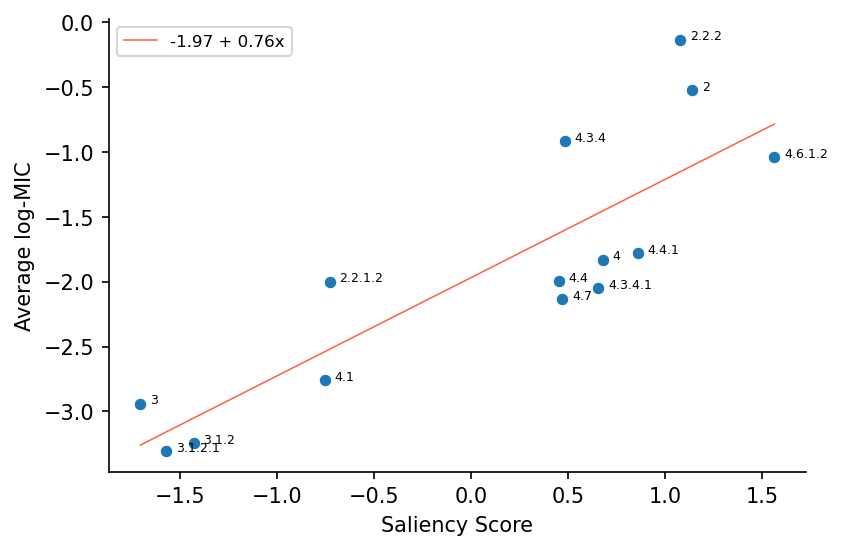

In [250]:
ax = sns.scatterplot(data=significant_lineages, x="plot_score", y="log-MIC")
print(st.pearsonr(np.squeeze(X), y))

for i, row in significant_lineages.iterrows():
    ax.text(row["plot_score"]+0.05, row["log-MIC"], row["Lineage"], color='black', fontsize=6)

# for i, row in significant_lineages.iterrows():
#     ax.text(row["plot_score"]+0.05, row["log-MIC"], row["position"], color='black', fontsize=6)

plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.75, label=f"{np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")
    
plt.legend(fontsize=8)
plt.xlabel("Saliency Score")
plt.ylabel("Average log-MIC")
sns.despine()
#plt.savefig("../Figures/moxi_lineage_analysis1.png", dpi=300)
plt.show()

In [252]:
moxi_gyrBA_lineage2_df.query("Max > 0 & max_pVal < 0.05").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,min_pVal,max_pVal,global_max_pVal,global_min_pVal
2575,gyrBA,7563.0,3.22992,0.0,0.0,1,0,NaN,0.000,0.000,1.0
1751,gyrBA,6742.0,3.214591,0.0,0.0,1,0,NaN,0.000,0.000,1.0
2584,gyrBA,7572.0,2.753326,0.0,0.0,1,0,NaN,0.000,0.000,1.0
2593,gyrBA,7581.0,2.655183,0.0,0.0,1,0,NaN,0.000,0.000,1.0
2578,gyrBA,7566.0,2.451479,0.0,0.0,0,0,NaN,0.000,0.000,1.0
2582,gyrBA,7570.0,2.418432,0.0,0.0,1,0,NaN,0.000,0.000,1.0
2594,gyrBA,7582.0,2.020795,0.0,0.0,1,0,NaN,0.000,0.000,1.0
1588,gyrBA,6579.0,1.749942,0.0,0.0,0,0,NaN,0.000,0.000,1.0
1745,gyrBA,6736.0,1.691598,0.0,0.0,0,0,NaN,0.000,0.000,1.0
1629,gyrBA,6620.0,1.668655,0.0,0.0,1,0,NaN,0.000,0.000,1.0


In [258]:
quant_sites = moxi_gyrBA_df.query("Max > 0 & max_pVal < 0.01")
binary_sites = moxi_gyrBA_binary_df.query("Max > 0 & max_pVal < 0.01")
lineage_sites = moxi_gyrBA_lineage2_df.query("Max > 0 & max_pVal < 0.01")
print(quant_sites.shape, binary_sites.shape, lineage_sites.shape)

(35, 11) (24, 11) (43, 11)


In [271]:
intersect = set(quant_sites["Pos"]).intersection(lineage_sites["Pos"]).intersection(binary_sites["Pos"])
search_sites = np.array(list(intersect)).astype(int).astype(str)
print(len(search_sites))

16


In [260]:
union = set(quant_sites["Pos"]).union(lineage_sites["Pos"]).union(binary_sites["Pos"])
len(union)

59

In [263]:
len(who_variants.query("drug=='MXF' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").genome_index.unique())

11

In [265]:
len(who_variants.query("drug=='MXF' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & genome_index in @search_sites").genome_index.unique())

10

In [267]:
len(set(lineage_sites["Pos"]) - set(binary_sites["Pos"]) - set(quant_sites["Pos"]))

19

In [279]:
len(set(quant_sites["Pos"]) - set(lineage_sites["Pos"]) - set(binary_sites["Pos"]))

9

In [275]:
set(quant_sites["Pos"]).intersection(set(lineage_sites["Pos"])) - set(binary_sites["Pos"])

{6575.0, 6576.0, 6738.0, 6749.0, 7230.0, 7378.0, 7510.0}

In [276]:
set(binary_sites["Pos"]).intersection(set(lineage_sites["Pos"])) - set(quant_sites["Pos"])

{6736.0}

In [277]:
set(binary_sites["Pos"]).intersection(set(quant_sites["Pos"])) - set(lineage_sites["Pos"])

{6583.0, 7567.0, 7585.0}

In [70]:
binary_sites.query("Pos in [6583.0, 6736.0]")

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,min_pVal,max_pVal,global_max_pVal,global_min_pVal
1592,gyrBA,6583.0,1.450174,0.0,0.0,0,0,NaN,0.0,0.0,1.0
1745,gyrBA,6736.0,3.946825,0.0,0.0,0,0,NaN,0.0,0.0,1.0


In [71]:
quant_sites.query("Pos in [6583.0, 6736.0]")

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,max_pVal,min_pVal,global_max_pVal,global_min_pVal
1592,gyrBA,6583.0,0.302662,0.0,0.0,0,0,0.001,NaN,0.001,1.0


In [72]:
lineage_sites.query("Pos in [6583.0, 6736.0]")

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,min_pVal,max_pVal,global_max_pVal,global_min_pVal
1745,gyrBA,6736.0,0.332559,0.0,0.0,0,0,NaN,0.0,0.0,1.0


In [74]:
quant_sites.query("Pos in [6575.0, 6576.0, 6738.0, 6749.0]")

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,max_pVal,min_pVal,global_max_pVal,global_min_pVal
1584,gyrBA,6575.0,0.822819,0.0,0.0,0,0,0.0,NaN,0.0,1.0
1585,gyrBA,6576.0,1.261453,0.0,0.0,0,0,0.0,NaN,0.0,1.0
1747,gyrBA,6738.0,0.533281,0.0,0.0,0,0,0.0,NaN,0.0,1.0
1758,gyrBA,6749.0,1.079279,0.0,0.0,0,0,0.0,NaN,0.0,1.0


In [75]:
lineage_sites.query("Pos in [6575.0, 6576.0, 6738.0, 6749.0]")

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,min_pVal,max_pVal,global_max_pVal,global_min_pVal
1584,gyrBA,6575.0,0.611311,0.0,0.0,0,0,NaN,0.0,0.0,1.0
1585,gyrBA,6576.0,0.438073,0.0,0.0,0,0,NaN,0.0,0.0,1.0
1747,gyrBA,6738.0,0.602276,0.0,0.0,0,0,NaN,0.0,0.0,1.0
1758,gyrBA,6749.0,1.254596,0.0,0.0,0,0,NaN,0.0,0.0,1.0


In [284]:
who_variants.query("drug=='MXF' & confidence=='3) Uncertain significance'").sort_values()

,Unnamed: 0,drug,genome_index,confidence,gene,variant
12739,12549,MXF,6735,3) Uncertain significance,gyrB,gyrB_N499T
12740,12550,MXF,7283,3) Uncertain significance,gyrA,gyrA_g-19t
12741,12551,MXF,6735,3) Uncertain significance,gyrB,gyrB_N499S
12742,12552,MXF,6052,3) Uncertain significance,gyrB,gyrB_I271M
12743,12553,MXF,7221,3) Uncertain significance,gyrB,gyrB_S661T
...,...,...,...,...,...,...
13292,13102,MXF,8668,3) Uncertain significance,gyrA,gyrA_A456V
13293,13103,MXF,6963,3) Uncertain significance,gyrB,gyrB_R575H
13294,13104,MXF,6446,3) Uncertain significance,gyrB,gyrB_A403S
13295,13105,MXF,5075,3) Uncertain significance,gyrB,gyrB_-165_ins_1_cg_cgt


In [287]:
who_variants.query("drug=='MXF'").loc[(who_variants.variant.str.contains("288")) & (~pd.isnull(who_variants.variant))]

,Unnamed: 0,drug,genome_index,confidence,gene,variant
12760,12570,MXF,8164,3) Uncertain significance,gyrA,gyrA_A288D
13275,13085,MXF,8164,3) Uncertain significance,gyrA,gyrA_A288V


In [9]:
bs_max_reps = []
bs_min_reps = []

num_bootstrap = 1000

for _ in range(num_bootstrap):
    bs_max_idx = np.random.choice(moxi_gyrBA_lineage_df.query("Max > 0").index, len(moxi_gyrBA_lineage_df.query("Max > 0")), replace=True)        
    bs_max_reps.append(np.mean(moxi_gyrBA_lineage_df.loc[bs_max_idx, "Max"].values))

    bs_min_idx = np.random.choice(moxi_gyrBA_lineage_df.query("Min < 0").index, len(moxi_gyrBA_lineage_df.query("Min < 0")), replace=True)
    bs_min_reps.append(np.mean(moxi_gyrBA_lineage_df.loc[bs_min_idx, "Min"].values))

    # bs_mean_idx = np.random.choice(single_df.query("Mean != 0").index, len(single_df.query("Mean != 0")), replace=True)        
    # bs_mean_reps.append(np.mean(single_df.loc[bs_mean_idx, "Mean"].values))

assert np.min(bs_max_reps) > 0
assert np.max(bs_min_reps) < 0

In [33]:
len(moxi_gyrBA_lineage_df.query("Max > 0")), len(moxi_gyrBA_lineage_df.query("Min < 0")), len(moxi_gyrBA_lineage_df)

(269, 237, 4831)

In [16]:
moxi_gyrBA_lineage_df.Max.min(), moxi_gyrBA_lineage_df.Min.max()

(0.0, 0.0)

In [24]:
moxi_gyrBA_lineage_df.Min.min(), moxi_gyrBA_lineage_df.Max.max()

(-0.4119151830673218, 2.854318141937256)

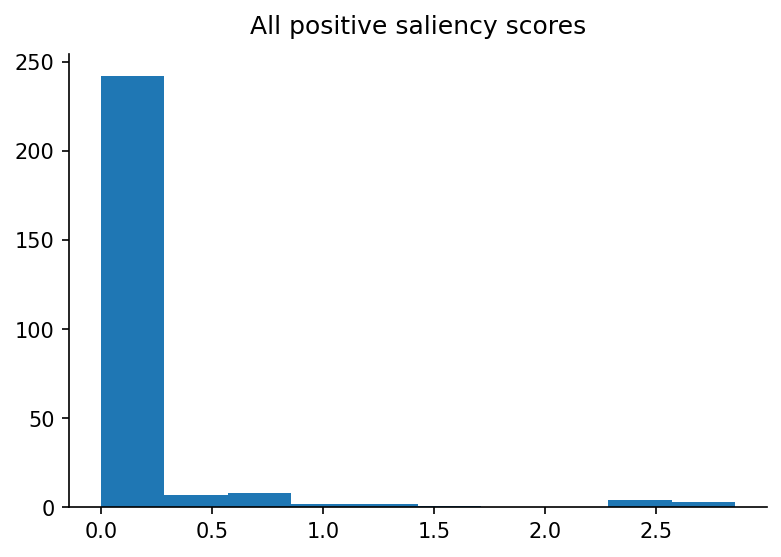

In [60]:
# sns.histplot(np.log(moxi_gyrBA_lineage_df.query("Max > 0")["Max"].values.astype(float)))
plt.hist(moxi_gyrBA_lineage_df.query("Max > 0")["Max"])

plt.title("All positive saliency scores")
sns.despine()
plt.show()

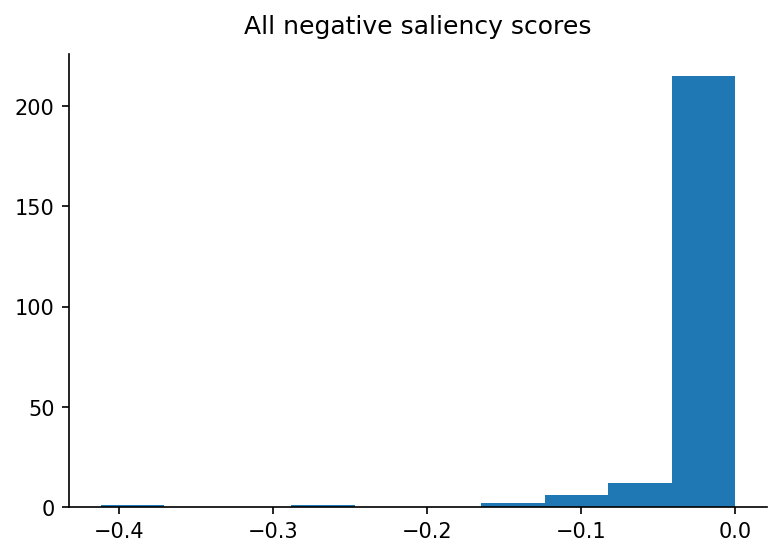

In [61]:
# sns.histplot(np.log(-moxi_gyrBA_lineage_df.query("Min < 0")["Min"].values.astype(float)))
plt.hist(moxi_gyrBA_lineage_df.query("Min < 0")["Min"])
plt.title("All negative saliency scores")
sns.despine()
plt.show()

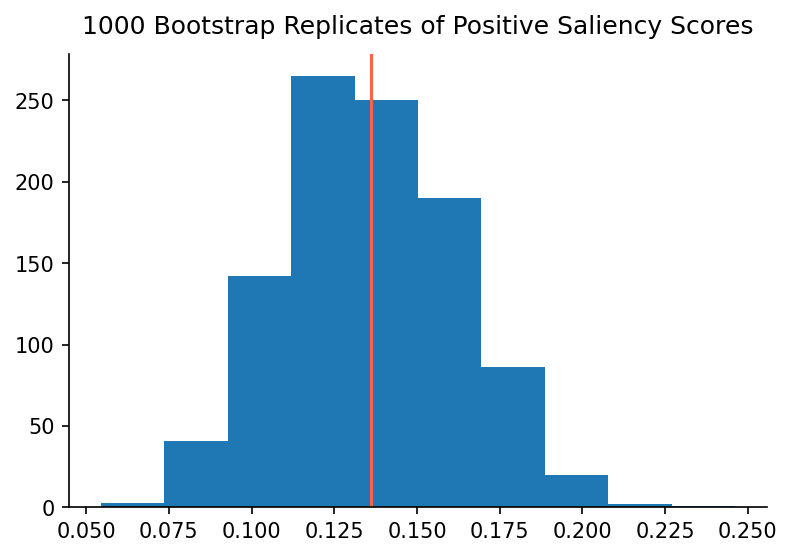

In [21]:
plt.hist(bs_max_reps)
plt.axvline(np.mean(bs_max_reps), color="tomato")
plt.title("1000 Bootstrap Replicates of Positive Saliency Scores")
sns.despine()

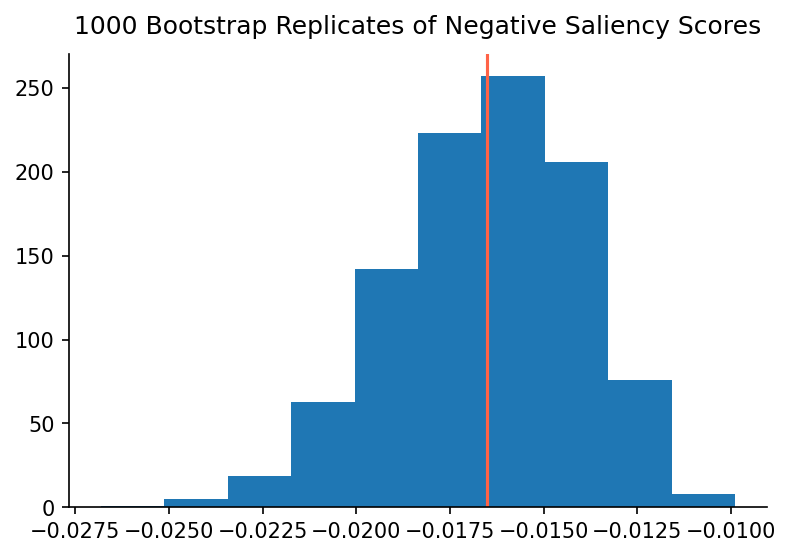

In [22]:
plt.hist(bs_min_reps)
plt.axvline(np.mean(bs_min_reps), color="tomato")
plt.title("1000 Bootstrap Replicates of Negative Saliency Scores")
sns.despine()

In [12]:
gyrBA_new_analysis = moxi_gyrBA_lineage_df.query("Max > 0 & max_pVal < 0.05 & Min == 0 & WHO == 0").sort_values("Max", ascending=False).reset_index(drop=True)

In [11]:
mean_mic = df_moxi["MOXI_midpoint"].mean()

for i, row in gyrBA_new_analysis.iterrows():
    
    variant = row["Pos"]
    
    ref = moxi_gyrBA_seq_dict["gyrBA"].loc["MT_H37Rv", variant]
    isolates_with_variant = moxi_gyrBA_seq_dict["gyrBA"].loc[moxi_gyrBA_seq_dict["gyrBA"][variant] != ref, variant].index.values
    
    #isolates_gyrBA = list(set(isolates_with_gyrBA_mut).intersection(isolates_with_variant))
    isolates_no_gyrBA = list(set(isolates_with_variant) - set(isolates_with_gyrBA_mut))
    
    #df_moxi.loc[df_moxi["ROLLINGDB_ID"].isin(isolates_gyrBA), "Variant"] = 'gyrBA + variant'
    
    # samples with the variant and no canonical gyrBA mutations vs. samples with neither
    variant_mics = df_moxi.loc[df_moxi["ROLLINGDB_ID"].isin(isolates_no_gyrBA)]["MOXI_midpoint"].values
    
    stat, bs_reps = two_sample_mean_bootstrap(variant_mics, mean_mic, num_bootstrap=1000)
    lower, upper = np.percentile(bs_reps, q=[2.5, 97.5])
    
    gyrBA_new_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper

In [13]:
gyrBA_new_analysis.query("log2_FC_LB > 1 & log2_FC_UB > 1")

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,max_pVal,min_pVal,global_max_pVal,global_min_pVal,log2_FC,log2_FC_LB,log2_FC_UB
0,gyrBA,7566.0,2.459419,0.0,0.0,0,0,0.0,1.0,0.0,1.0,2.907738,2.763264,3.057380
2,gyrBA,6735.0,1.106627,0.0,0.0,0,0,0.0,1.0,0.0,1.0,1.819053,1.586169,2.051732
4,gyrBA,7521.0,0.814258,0.0,0.0,0,0,0.0,1.0,0.0,1.0,1.660441,1.549783,1.794020
8,gyrBA,8164.0,0.574312,0.0,0.0,0,0,0.0,1.0,0.0,1.0,2.170475,1.966351,2.377055


In [48]:
# only 5 with gyrBA or the variant at all
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

no variant      6005
gyrBA           1192
variant only      12
Name: Variant, dtype: int64
Variant
gyrBA           2.319002
no variant      0.174541
variant only    3.975208
Name: MOXI_midpoint, dtype: float64


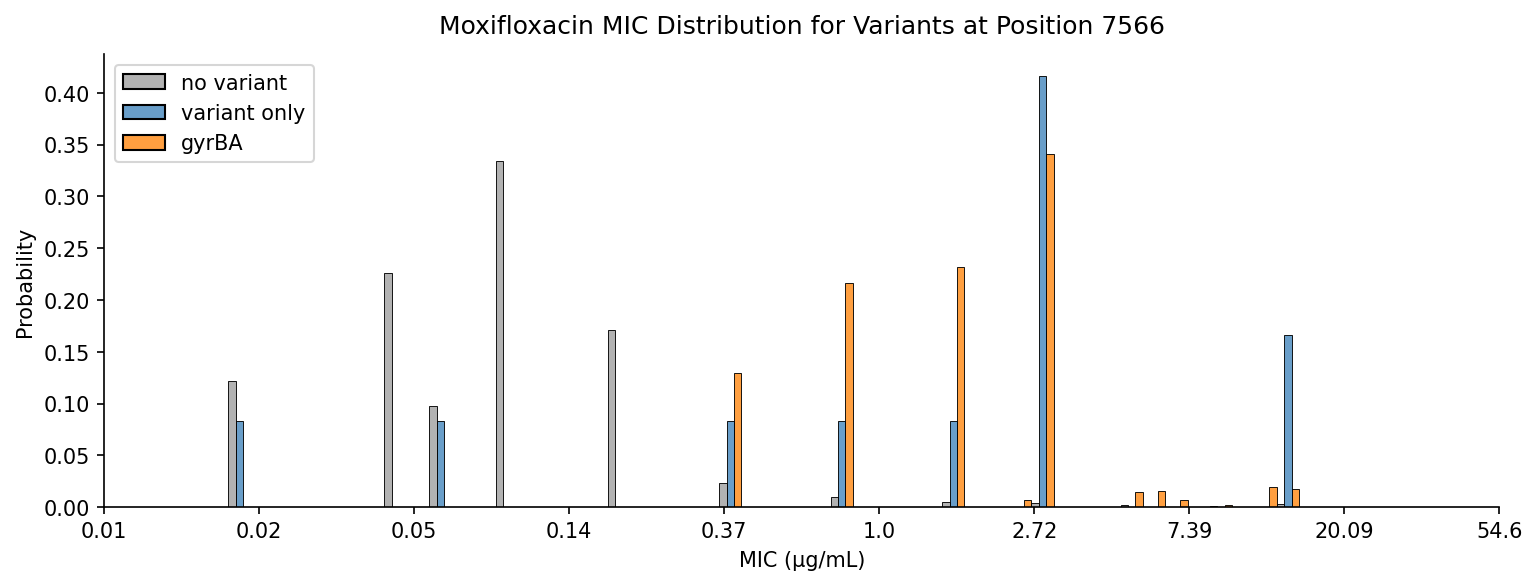

In [61]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [50]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

no variant      6008
gyrBA           1192
variant only       9
Name: Variant, dtype: int64
Variant
gyrBA           2.319002
no variant      0.179599
variant only    1.865278
Name: MOXI_midpoint, dtype: float64


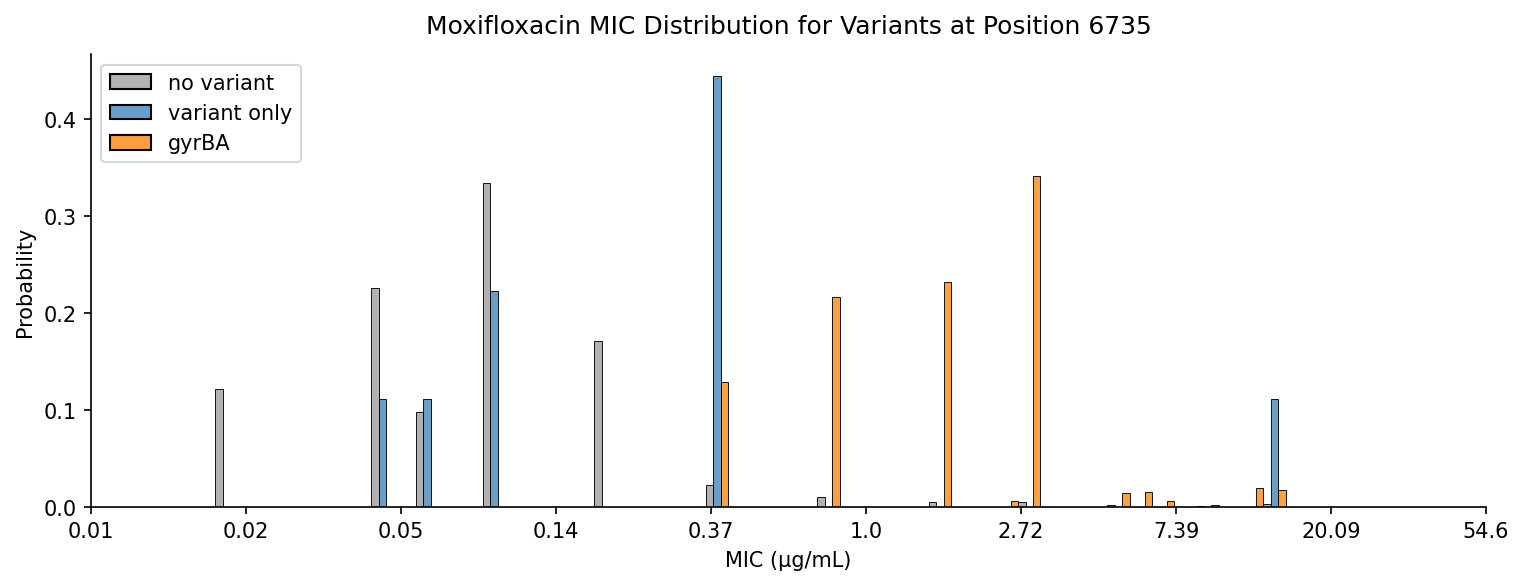

In [28]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

no variant      6008
gyrBA           1192
variant only       9
Name: Variant, dtype: int64
Variant
gyrBA           2.319002
no variant      0.178803
variant only    2.397222
Name: MOXI_midpoint, dtype: float64


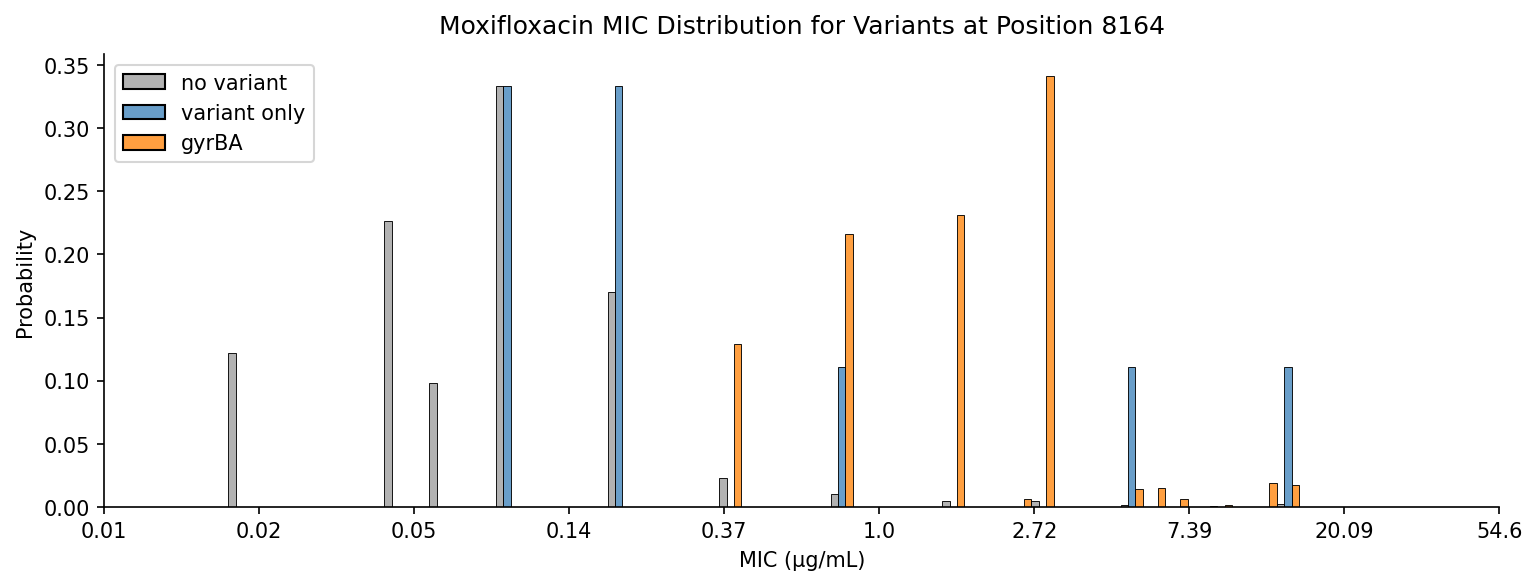

In [60]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [16]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [17]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Rifampicin

1 loci!
SNP values: [0.  0.5 1. ]
1 loci, longest locus: 7864, 7584 isolates, 0 lineage SNPs
58 Cat 1/2 WHO catalog sites for ['RIF']
12 Cat 1/2 WHO catalog sites not found
Sites not found: [761080 761082 761094 761121 761122 761131 761134 761135 761143 761150
 761151 761159]
Performing bootstrapping with 1000 replicates...


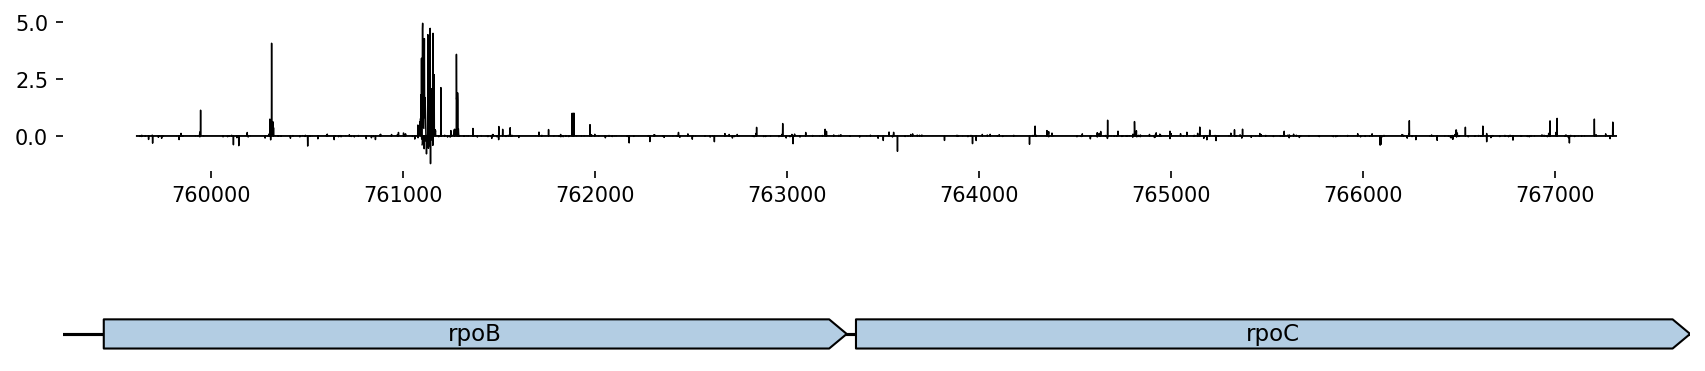

In [5]:
rif_rpoBC_df, rif_rpoBC_seq_dict = generate_saliency_plots("config_rif.yaml",
                                                             ["RIF"],
                                                             cat_to_check=["1", "2"],
                                                             binary=False,
                                                             isolate_variants_df=None,
                                                             num_bootstrap=1000, 
                                                             save=True
                                                            )

In [133]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

(1744, 8)


In [134]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

(1779, 6)


In [135]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

(1162, 15)
(25, 15)


In [136]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

(25, 16)


In [137]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

,Gene,Pos,Max,Min,Mean,WHO,Lineage_SNP,max_pVal,min_pVal,global_max_pVal,global_min_pVal,drug,confidence,gene,variant,Num_Isolates
114,rpoBC,761880.0,0.99916,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoB,rpoB_A692T,86
47,rpoBC,761277.0,3.593972,0.0,-9.285206e-07,1.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoB,rpoB_I491Y,37
48,rpoBC,761277.0,3.593972,0.0,-9.285206e-07,1.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoB,rpoB_I491L,37
49,rpoBC,761277.0,3.593972,0.0,-9.285206e-07,1.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoB,rpoB_I491V,37
126,rpoBC,764810.0,0.632927,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoC,rpoC_P481T,27
127,rpoBC,764810.0,0.632927,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoC,rpoC_P481S,27
143,rpoBC,761973.0,0.497222,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoB,rpoB_H723D,10
82,rpoBC,761279.0,1.783254,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoB,rpoB_I491M,8
124,rpoBC,766242.0,0.670552,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoC,rpoC_T958N,7
125,rpoBC,766242.0,0.670552,0.0,-9.285206e-07,0.0,0.0,0.0,1.0,0.000,1.0,RIF,3) Uncertain significance,rpoC,rpoC_T958I,7


Variant
canonical mut + variant    73.826087
canonical mut only         19.139346
no variants                 0.852819
variant only                2.546250
Name: RIF_midpoint, dtype: float64
no variants                5080
canonical mut only         4374
canonical mut + variant      23
variant only                  4
Name: Variant, dtype: int64


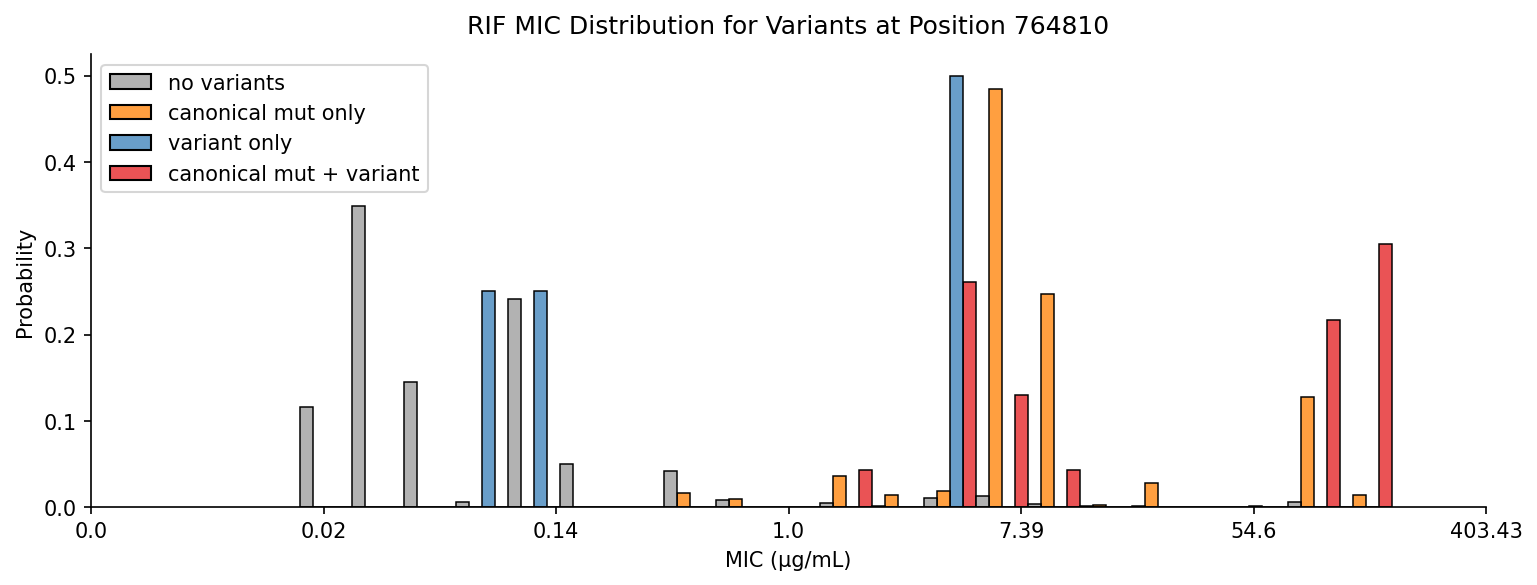

Variant
canonical mut + variant     6.000000
canonical mut only         19.428458
no variants                 0.852402
variant only                2.631000
Name: RIF_midpoint, dtype: float64
no variants                5079
canonical mut only         4396
variant only                  5
canonical mut + variant       1
Name: Variant, dtype: int64


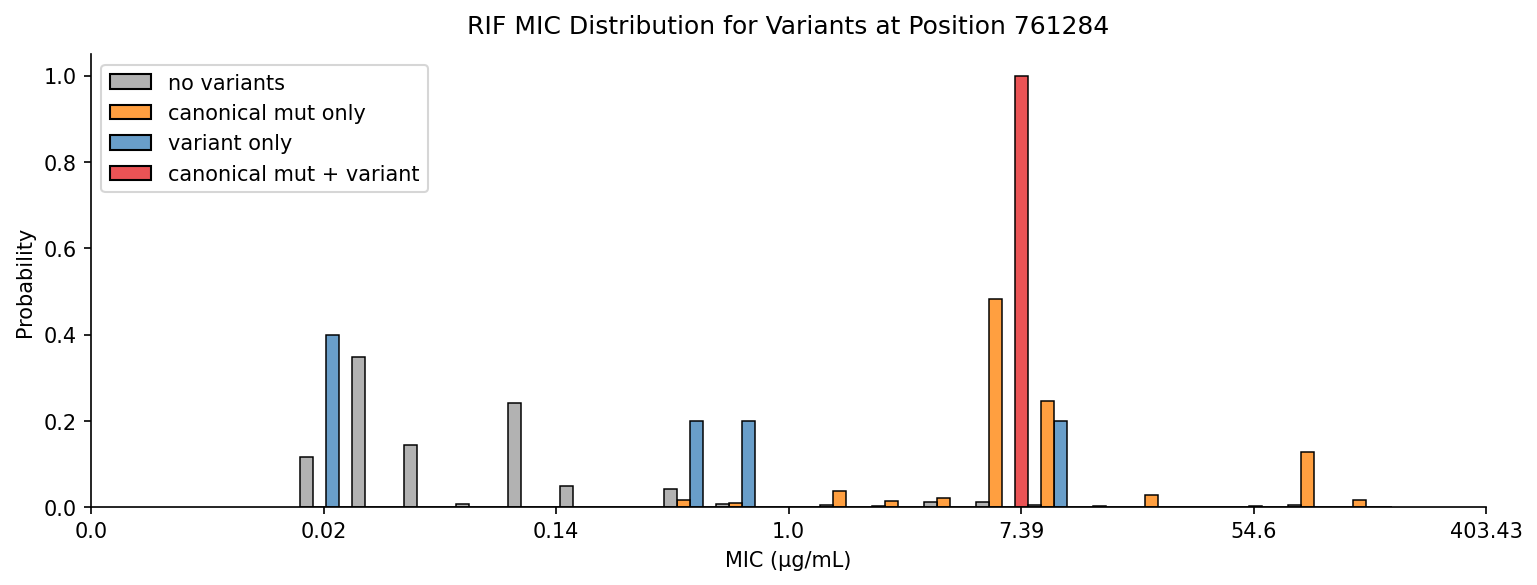

Variant
canonical mut + variant    25.125000
canonical mut only         19.420214
no variants                 0.853159
variant only                3.375000
Name: RIF_midpoint, dtype: float64
no variants                5082
canonical mut only         4393
canonical mut + variant       4
variant only                  2
Name: Variant, dtype: int64


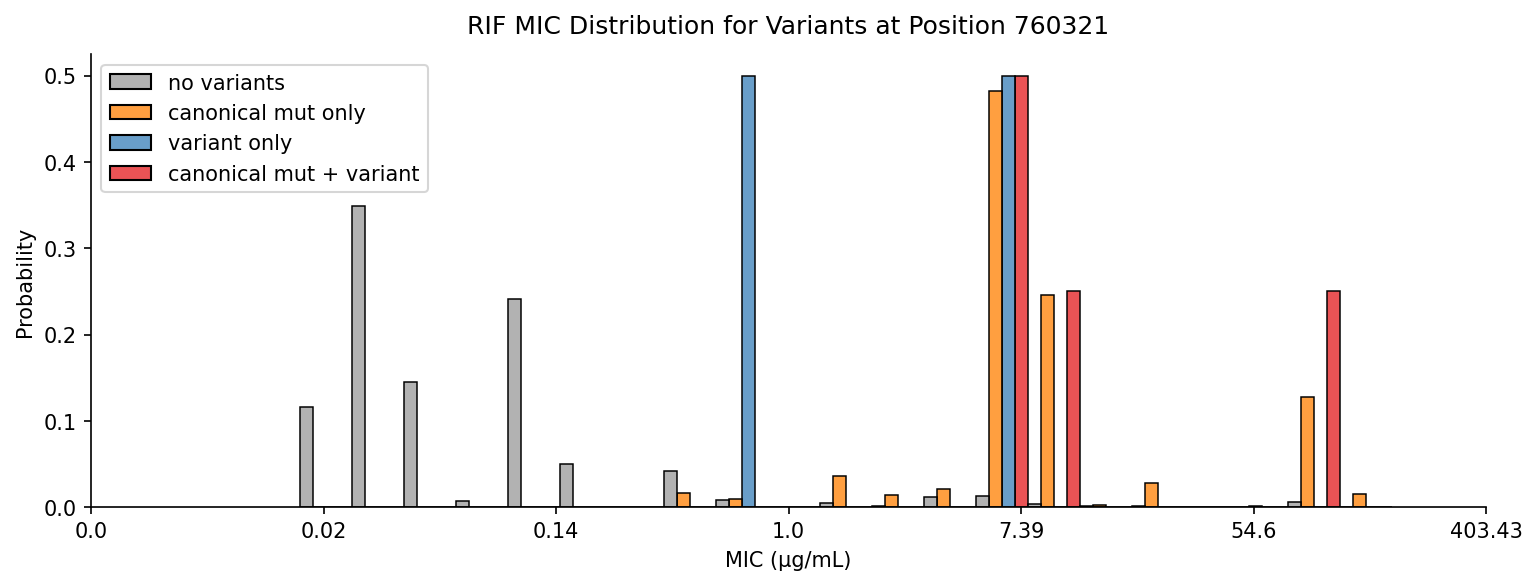

In [178]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [139]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [146]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [19]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [32]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [140]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [177]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [17]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [41]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [42]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [43]:
test.shape

(6017, 30)

In [38]:
4819/(4819+1198)

0.800897457204587

In [39]:
1198/(4819+1198)

0.199102542795413

In [40]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

category
original_test_set     0.186525
original_train_set    0.181026
Name: MOXI_midpoint, dtype: float64

In [140]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

15.0

In [141]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

15.0

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [116]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

4 loci!
4 loci, longest locus: 5822, 5767 isolates


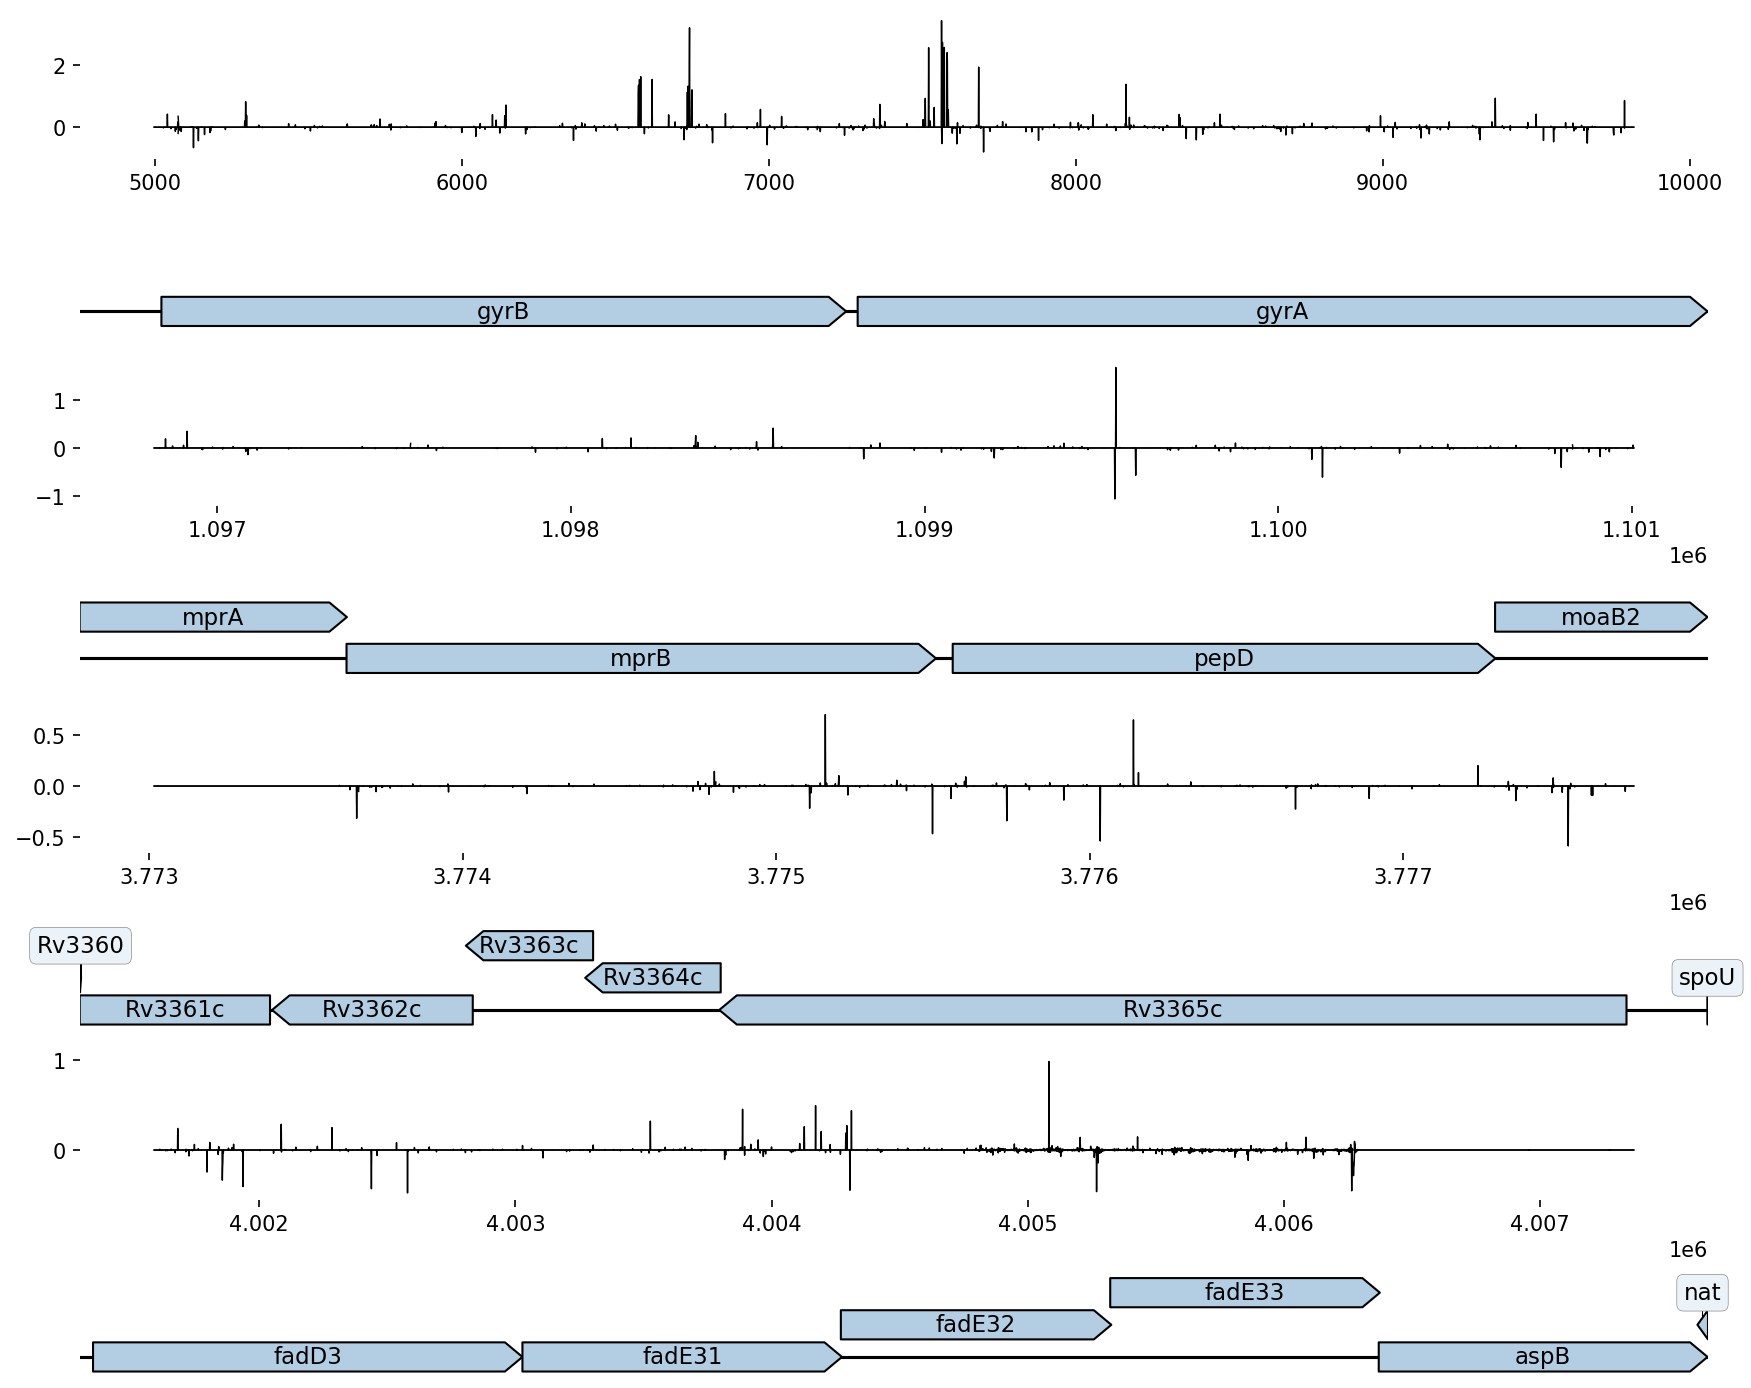

11 Cat 1/2 WHO catalog sites for ['MXF']
CNN found all Cat 1/2 WHO catalog sites for ['MXF']
Performing bootstrapping with 1000 replicates...


In [8]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

12 loci!
12 loci, longest locus: 5822, 5767 isolates


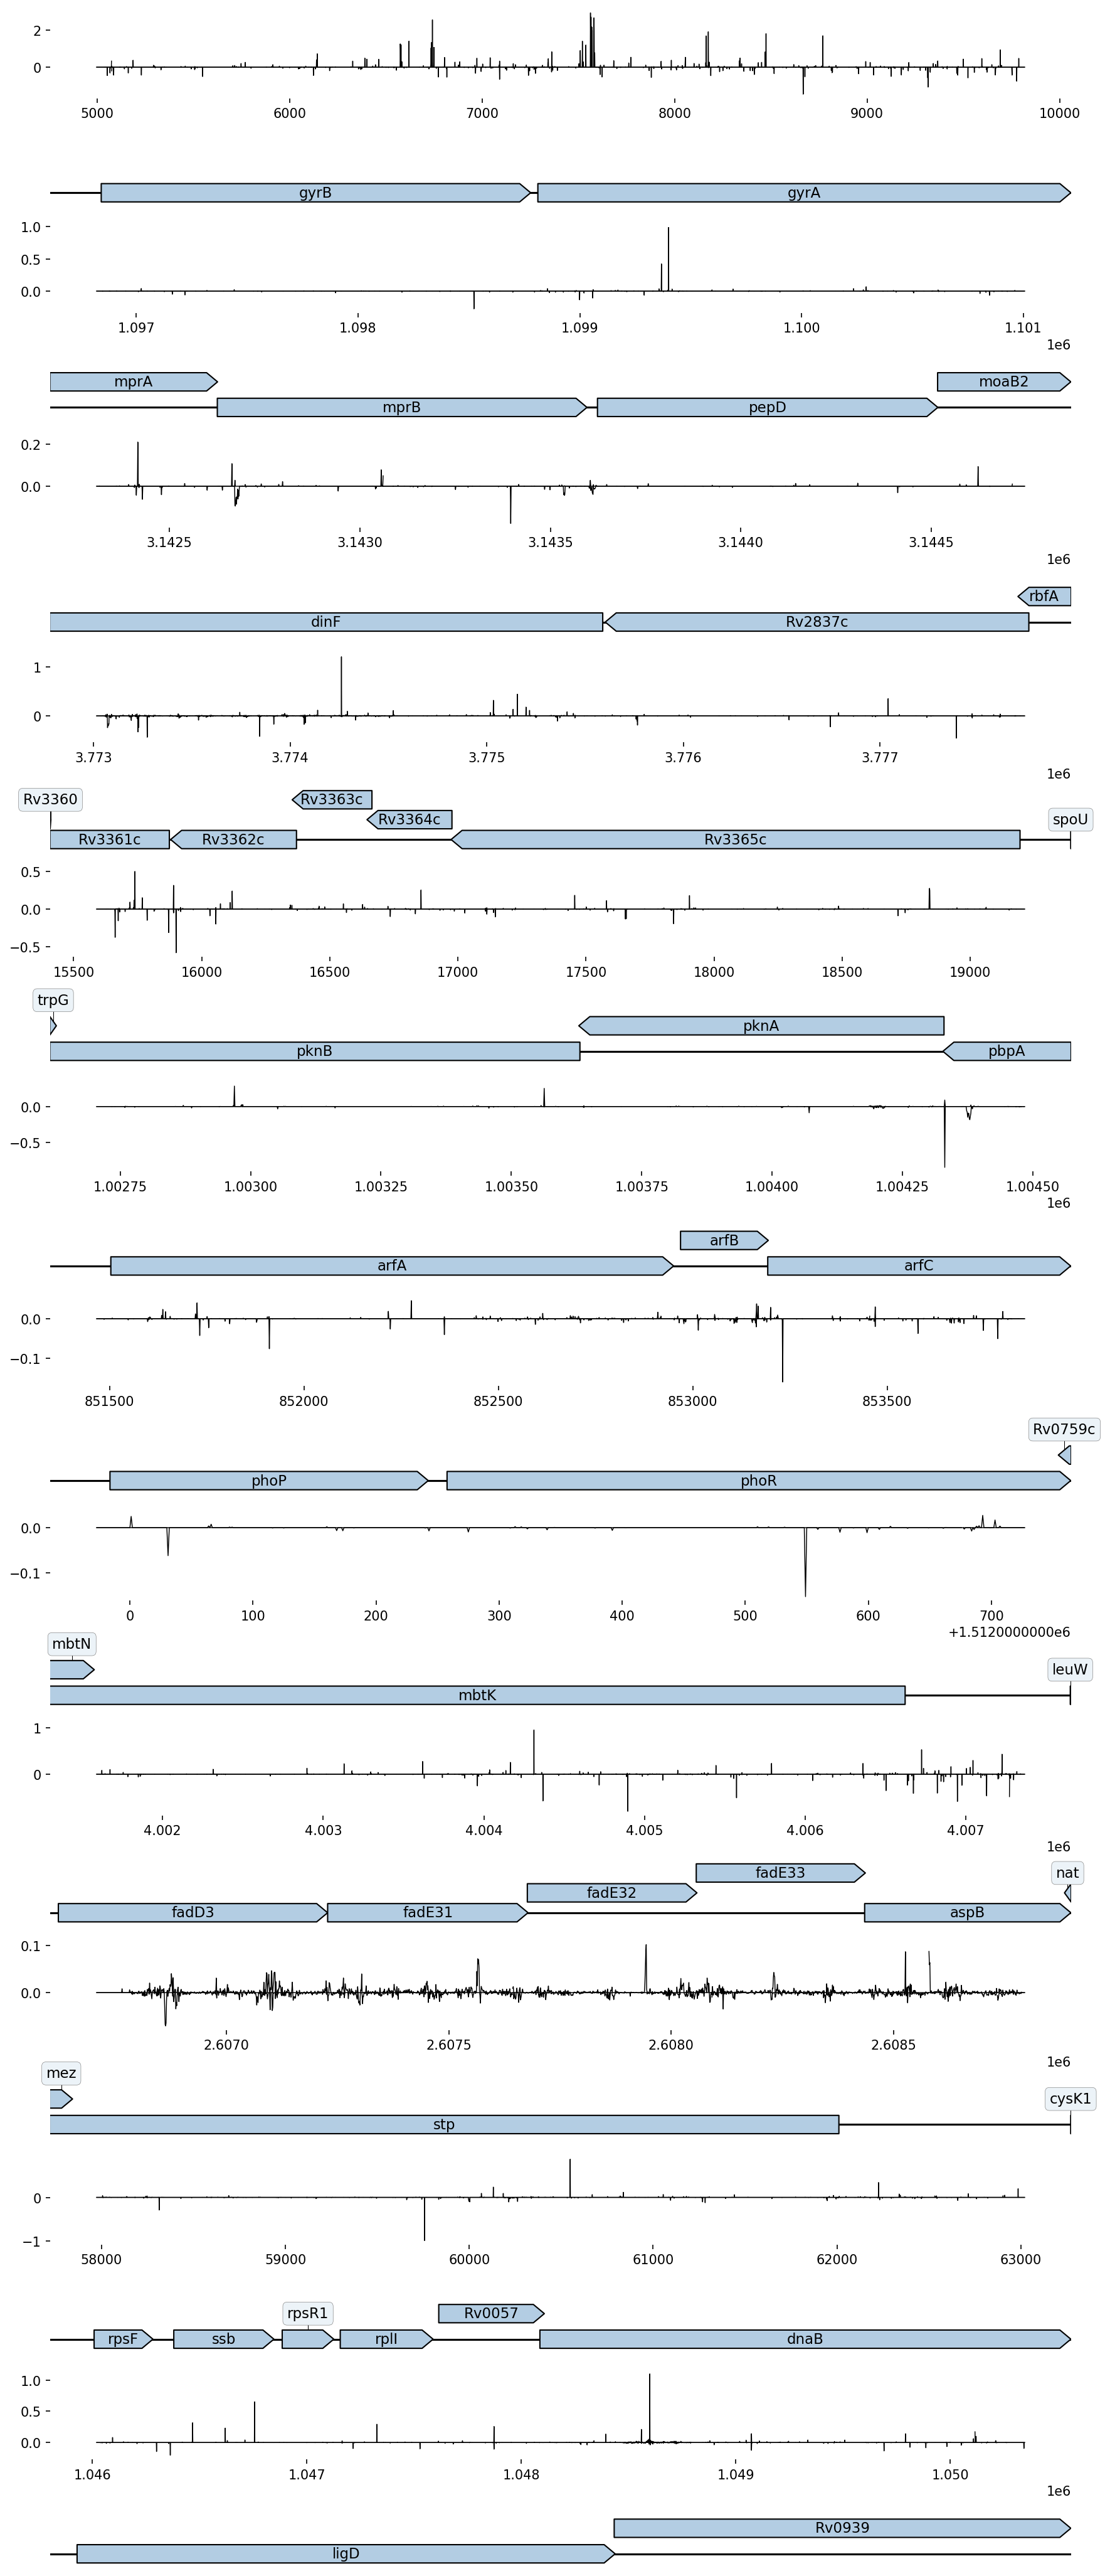

11 Cat 1/2 WHO catalog sites for ['MXF']
CNN found all Cat 1/2 WHO catalog sites for ['MXF']
Performing bootstrapping with 1000 replicates...


In [6]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())

# Analysis of Gyrase vs. Other Mutations

# Troubleshooting Position Assignments

In [ ]:
locus = "Rv3361c_Rv3365c"
fastas_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220710_moxi_7genes/fastas"
idx = locus_list.index(locus)

fastas = [os.path.join(fastas_path, gene + ".fasta") for gene in locus_list]
print(f"{len(fastas)} loci!")

# make the genetic coordinates dataframe. Includes strand sense and locus length
gene_coords = get_gene_coords(locus_list, fastas_path, sense_dict)
gene_to_fasta = dict(zip(locus_list, fastas))
X_matrix_H37Rv_coords = make_h37rv_coordinates(gene_coords, locus_list, gene_to_fasta)

seqs = [(os.path.basename(seq.id).split(".")[0], str(seq.seq)) for seq in SeqIO.parse(f"{fastas_path}/{locus}.fasta", "fasta")]
H37Rv_locus = seqs[-1][1]

aln_len = len(H37Rv_locus)
seq_df = pd.DataFrame(seqs).rename(columns={0:"Isolate", 1:"seq"})
isolates = seq_df.Isolate.values

seq_df = seq_df.seq.str.split("", expand=True).iloc[:, 1:-1].T.reset_index(drop=True)
seq_df.columns = isolates

# the alignment length should be the same or longer (indels) as the H37Rv reference sequence
assert aln_len >= gene_coords.loc[locus, "Length"]

print(f"Finding deletions in isolates relative to H37Rv")
del_idx = []
for i, row in seq_df.iterrows():

    if ("-" in seq_df.loc[i, :].values) & (row["MT_H37Rv"] != "-"):
        assert ~pd.isnull(i)
        del_idx.append(int(i))

del_pos = X_matrix_H37Rv_coords[del_idx, idx]
print(len(del_pos), aln_len)

In [ ]:
mfpA_new = get_locus_adj_coords_updated(X_matrix_H37Rv_coords, gene_coords, locus_list, combined_max, combined_min, fastas_path, locus, moxi_isolate_variants)

In [ ]:
mfpA_new

In [ ]:
moxi_7loci_nonZero.query("Pos==3774261")

In [ ]:
mfpA_new.query("Pos==3774261")

In [ ]:
gene_coords

In [ ]:
output_path = '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220710_moxi_7genes'
combined_mean = np.load(os.path.join(output_path, "deeplift_outputs", "deeplift_mean.npy")).squeeze()
combined_max = np.load(os.path.join(output_path, "deeplift_outputs", "deeplift_max.npy")).squeeze()
combined_min = np.load(os.path.join(output_path, "deeplift_outputs", "deeplift_min.npy")).squeeze()

In [ ]:
del_pos[:20]

In [ ]:
3774261 in del_pos

In [ ]:
seq_df.index = X_matrix_H37Rv_coords[:, idx][:aln_len]

In [ ]:
seq_df.loc[3774261].unique()

In [ ]:
np.where(seq_df.loc[3774261].values == '-')

In [ ]:
seq_df.columns[1989]

In [ ]:
moxi_7loci_batched_nonZero.query("Pos==3773030")

In [ ]:
moxi_7loci_batched_nonZero.query("Gene=='Rv3361c_Rv3365c'").sort_values("Pos")

In [ ]:
#list(seq_df['ERR4796809'].values)

In [ ]:
moxi_isolate_variants.query("Isolate=='ERR4796809' & POS > 3770000 & POS <= 3774300")

In [ ]:
df_phenos_moxi.query("ROLLINGDB_ID=='ERR4796809'")

In [ ]:
3773030+1502

In [ ]:
gene_coords

In [ ]:
seq_df.loc[3774261, seq_df.columns[1989]]

In [ ]:
stp_new = get_locus_adj_coords_updated(X_matrix_H37Rv_coords, gene_coords, locus_list, combined_max, combined_min, fastas_path, "stp")
mfpA_new = get_locus_adj_coords_updated(X_matrix_H37Rv_coords, gene_coords, locus_list, combined_max, combined_min, fastas_path, "Rv3361c_Rv3365c")

In [ ]:
mfpA_new = get_locus_adj_coords_updated(X_matrix_H37Rv_coords, gene_coords, locus_list, combined_max, combined_min, fastas_path, "Rv3361c_Rv3365c")

In [ ]:
mfpA_new.sort_values("Max", ascending=False).head()

In [ ]:
mfpA_new.sort_values("Min", ascending=True).head()

In [ ]:
mfpA_new.query("Pos==3774261")

In [ ]:
mfpA_new.iloc[3470:3480]

In [ ]:
stp_new.sort_values("Max", ascending=False).head()

In [ ]:
stp_new.sort_values("Min", ascending=True).head()

In [ ]:
moxi_isolate_variants.query("POS == 3774261")

In [ ]:
moxi_isolate_variants.query("POS in [2608117.0]")

In [ ]:
ompA_new.query("Pos==1002981")

In [ ]:
ompA_new.query("Pos in [1002982, 1002983, 1002984, 1002985, 1003026]")

In [ ]:
ompA_new.query("Pos == 1003026")

In [ ]:
gene_coords

In [ ]:
idx_large

In [ ]:
moxi_isolate_variants.query("POS <= 3777736 & POS >= 3773016").iloc[idx_large, :]

## The next 2 cells aren't needed because they don't significantly improve interpretation of results

In [ ]:
# # Merging promoters for plus strand
# promoter_location_data1 = pd.read_csv("../inputs/promoters_plus_strand.csv")
# data = promoter_location_data1.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 74

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# print(len(data), len(output_data))
# promoter_location_data1= output_data

# # Merging promoters for minus strand
# promoter_location_data2 = pd.read_csv("../inputs/promoters_minus_strand.csv")
# data = promoter_location_data2.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# data = data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 0

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# output_data = output_data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# print(len(data), len(output_data))
# promoter_location_data2= output_data

In [ ]:
# Add promoter annotations to genome
# H37Rv Genome

# for idx,row in promoter_location_data1.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.upstream, row.downstream, 1
#     ), feature_type="promoter")
    
# for idx,row in promoter_location_data2.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.downstream, row.upstream, -1
#     ), feature_type="promoter")